# W&B Group MAE Curves

Edit `ENTITY`, `PROJECT`, and `GROUP_NAMES`, then run the notebook. The W&B API key is loaded from `../.slurm_tokens` without printing it.

In [10]:
from __future__ import annotations

import os
import shlex
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import wandb

plt.style.use("seaborn-v0_8-whitegrid")

## Configure

In [11]:
# Fill these in from your W&B workspace.
ENTITY = "mhenheik-eth-z-rich"  # e.g. "your-wandb-username-or-team"
PROJECT = "cil-sentiment"

GROUP_NAMES = [
    "Default",
    "GradVac",
    "PCGrad"
]

# The first metric found in each run history is used.
# Put eval/rounded_mae first because that is the MAE logged by these runs.
MAE_METRIC_CANDIDATES = [
    "eval/rounded_mae",
    "eval/mae",
    "eval/bayes_mae",
    "eval/map_mae",
    "eval/tuned_threshold_mae",
    "val_prediction_primary_mae",
    "mae",
    "bayes_mae",
    "rounded_mae",
    "map_mae",
    "tuned_threshold_mae",
]

X_AXIS_CANDIDATES = ["train/global_step", "global_step", "trainer/global_step"]
FALLBACK_EVAL_STEP_INTERVAL = 500
FALLBACK_LOGGING_STEP_INTERVAL = 500
TRAIN_LOSS_METRIC_CANDIDATES = ["train/loss", "loss"]

# None means scan every history row W&B recorded for each run.
MAX_HISTORY_ROWS_PER_RUN = None

## Login

In [12]:
def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".slurm_tokens").exists():
            return candidate
    raise FileNotFoundError("Could not find .slurm_tokens in this directory or its parents.")


def load_shell_exports(path: Path) -> dict[str, str]:
    values: dict[str, str] = {}
    for raw_line in path.read_text().splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#"):
            continue
        if line.startswith("export "):
            line = line[len("export ") :]
        if "=" not in line:
            continue
        key, value = line.split("=", 1)
        values[key.strip()] = shlex.split(value)[0] if value else ""
    return values


repo_root = find_repo_root()
tokens = load_shell_exports(repo_root / ".slurm_tokens")

if "WANDB_API_KEY" not in os.environ and tokens.get("WANDB_API_KEY"):
    os.environ["WANDB_API_KEY"] = tokens["WANDB_API_KEY"]

wandb.login(key=os.environ.get("WANDB_API_KEY"), relogin=False)
api = wandb.Api()

print("Logged in to W&B. Token was loaded from .slurm_tokens and not displayed.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/micha/.netrc


Logged in to W&B. Token was loaded from .slurm_tokens and not displayed.


## Fetch Runs

In [13]:
def history_rows_for_metric(run: wandb.apis.public.Run, metric: str) -> list[dict]:
    rows = []
    # Do not pass keys here: W&B can drop sparse eval rows when key-filtering.
    # Scanning raw rows and filtering locally keeps every recorded eval point.
    for idx, row in enumerate(run.scan_history(page_size=1000)):
        if metric in row and pd.notna(row[metric]):
            rows.append(row)
        if MAX_HISTORY_ROWS_PER_RUN is not None and idx + 1 >= MAX_HISTORY_ROWS_PER_RUN:
            break
    return rows


def eval_step_interval(run: wandb.apis.public.Run) -> int:
    config = run.config or {}
    if isinstance(config.get("training"), dict) and config["training"].get("eval_steps"):
        return int(config["training"]["eval_steps"])
    for key in ["training.eval_steps", "eval_steps", "args/eval_steps"]:
        if config.get(key):
            return int(config[key])
    return FALLBACK_EVAL_STEP_INTERVAL


def logging_step_interval(run: wandb.apis.public.Run) -> int:
    config = run.config or {}
    if isinstance(config.get("training"), dict) and config["training"].get("logging_steps"):
        return int(config["training"]["logging_steps"])
    for key in ["training.logging_steps", "logging_steps", "args/logging_steps"]:
        if config.get(key):
            return int(config[key])
    return FALLBACK_LOGGING_STEP_INTERVAL


def step_from_row(row: dict, fallback: int) -> int | float:
    for key in X_AXIS_CANDIDATES:
        if key in row and pd.notna(row[key]):
            return row[key]
    return fallback


def run_history_frame(run: wandb.apis.public.Run) -> pd.DataFrame:
    for metric in MAE_METRIC_CANDIDATES:
        rows = history_rows_for_metric(run, metric)
        if not rows:
            continue

        interval = eval_step_interval(run)
        frame = pd.DataFrame(
            {
                "step": [step_from_row(row, (idx + 1) * interval) for idx, row in enumerate(rows)],
                "wandb_step": [row.get("_step") for row in rows],
                "mae": [row[metric] for row in rows],
            }
        ).dropna()
        if frame.empty:
            continue

        frame["group"] = run.group or "<no group>"
        frame["run_name"] = run.name
        frame["run_id"] = run.id
        frame["metric"] = metric
        return frame.sort_values("step")

    return pd.DataFrame()


def run_loss_frame(run: wandb.apis.public.Run) -> pd.DataFrame:
    for metric in TRAIN_LOSS_METRIC_CANDIDATES:
        rows = history_rows_for_metric(run, metric)
        if not rows:
            continue

        interval = logging_step_interval(run)
        frame = pd.DataFrame(
            {
                "step": [step_from_row(row, (idx + 1) * interval) for idx, row in enumerate(rows)],
                "wandb_step": [row.get("_step") for row in rows],
                "loss": [row[metric] for row in rows],
            }
        ).dropna()
        if frame.empty:
            continue

        frame["group"] = run.group or "<no group>"
        frame["run_name"] = run.name
        frame["run_id"] = run.id
        frame["metric"] = metric
        return frame.sort_values("step")

    return pd.DataFrame()


if not ENTITY:
    raise ValueError("Please set ENTITY in the configure cell before fetching runs.")
if not GROUP_NAMES:
    raise ValueError("Please add at least one group name to GROUP_NAMES.")

runs = list(api.runs(
    path=f"{ENTITY}/{PROJECT}",
    filters={"group": {"$in": GROUP_NAMES}},
))
print(f"Found {len(runs)} runs in groups: {GROUP_NAMES}")

frames = []
for run in runs:
    frame = run_history_frame(run)
    if not frame.empty:
        frames.append(frame)

if not frames:
    available = []
    for run in runs[:10]:
        summary_keys = sorted(key for key in run.summary.keys() if "mae" in key.lower())
        available.append({"group": run.group, "run_name": run.name, "summary_mae_keys": summary_keys})
    display(pd.DataFrame(available))
    raise RuntimeError(
        "No MAE histories found. The diagnostic table above shows MAE-like summary keys from the first runs."
    )

df = pd.concat(frames, ignore_index=True)
display(
    df.groupby(["group", "run_name", "metric"], as_index=False)
      .agg(points=("mae", "size"), min_mae=("mae", "min"), last_step=("step", "max"), last_wandb_step=("wandb_step", "max"))
      .sort_values(["group", "min_mae"])
)

df.head()

Found 9 runs in groups: ['Default', 'GradVac', 'PCGrad']


,group,run_name,metric,points,min_mae,last_step,last_wandb_step
0,Default,lora_bert_base_seed1_lora_bert_default_default,eval/rounded_mae,36,0.378810,17720,70
1,Default,lora_bert_base_seed2_lora_bert_default_default,eval/rounded_mae,36,0.381230,17720,70
2,Default,lora_bert_base_seed3_lora_bert_default_default,eval/rounded_mae,36,0.384087,17720,70
3,GradVac,lora_bert_base_seed1_lora_bert_default_gradvac,eval/rounded_mae,36,0.384960,17720,70
4,GradVac,lora_bert_base_seed2_lora_bert_default_gradvac,eval/rounded_mae,36,0.387857,17720,70
5,GradVac,lora_bert_base_seed3_lora_bert_default_gradvac,eval/rounded_mae,36,0.389564,17720,70
6,PCGrad,lora_bert_base_seed1_lora_bert_default_pcgrad,eval/rounded_mae,36,0.384762,17720,70
8,PCGrad,lora_bert_base_seed3_lora_bert_default_pcgrad,eval/rounded_mae,36,0.389405,17720,70
7,PCGrad,lora_bert_base_seed2_lora_bert_default_pcgrad,eval/rounded_mae,36,0.390198,17720,70


,step,wandb_step,mae,group,run_name,run_id,metric
0,500,1,0.492063,Default,lora_bert_base_seed1_lora_bert_default_default,v4gu5ea5,eval/rounded_mae
1,1000,3,0.425794,Default,lora_bert_base_seed1_lora_bert_default_default,v4gu5ea5,eval/rounded_mae
2,1500,5,0.415556,Default,lora_bert_base_seed1_lora_bert_default_default,v4gu5ea5,eval/rounded_mae
3,2000,7,0.417540,Default,lora_bert_base_seed1_lora_bert_default_default,v4gu5ea5,eval/rounded_mae
4,2500,9,0.409524,Default,lora_bert_base_seed1_lora_bert_default_default,v4gu5ea5,eval/rounded_mae


## Fetch Training Loss

In [14]:
loss_frames = []
for run in runs:
    frame = run_loss_frame(run)
    if not frame.empty:
        loss_frames.append(frame)

if not loss_frames:
    available = []
    for run in runs[:10]:
        summary_keys = sorted(key for key in run.summary.keys() if "loss" in key.lower())
        available.append({"group": run.group, "run_name": run.name, "summary_loss_keys": summary_keys})
    display(pd.DataFrame(available))
    raise RuntimeError(
        "No training loss histories found. The diagnostic table above shows loss-like summary keys from the first runs."
    )

loss_df = pd.concat(loss_frames, ignore_index=True)
display(
    loss_df.groupby(["group", "run_name", "metric"], as_index=False)
      .agg(points=("loss", "size"), min_loss=("loss", "min"), last_step=("step", "max"), last_wandb_step=("wandb_step", "max"))
      .sort_values(["group", "min_loss"])
)

loss_df.head()

,group,run_name,metric,points,min_loss,last_step,last_wandb_step
2,Default,lora_bert_base_seed3_lora_bert_default_default,train/loss,35,0.136047,17500,68
1,Default,lora_bert_base_seed2_lora_bert_default_default,train/loss,35,0.136148,17500,68
0,Default,lora_bert_base_seed1_lora_bert_default_default,train/loss,35,0.137408,17500,68
3,GradVac,lora_bert_base_seed1_lora_bert_default_gradvac,train/loss,35,0.084537,17500,68
5,GradVac,lora_bert_base_seed3_lora_bert_default_gradvac,train/loss,35,0.084538,17500,68
4,GradVac,lora_bert_base_seed2_lora_bert_default_gradvac,train/loss,35,0.086109,17500,68
7,PCGrad,lora_bert_base_seed2_lora_bert_default_pcgrad,train/loss,35,0.082609,17500,68
8,PCGrad,lora_bert_base_seed3_lora_bert_default_pcgrad,train/loss,35,0.083324,17500,68
6,PCGrad,lora_bert_base_seed1_lora_bert_default_pcgrad,train/loss,35,0.085532,17500,68


,step,wandb_step,loss,group,run_name,run_id,metric
0,500,0,0.300153,Default,lora_bert_base_seed1_lora_bert_default_default,v4gu5ea5,train/loss
1,1000,2,0.201486,Default,lora_bert_base_seed1_lora_bert_default_default,v4gu5ea5,train/loss
2,1500,4,0.189218,Default,lora_bert_base_seed1_lora_bert_default_default,v4gu5ea5,train/loss
3,2000,6,0.188305,Default,lora_bert_base_seed1_lora_bert_default_default,v4gu5ea5,train/loss
4,2500,8,0.181443,Default,lora_bert_base_seed1_lora_bert_default_default,v4gu5ea5,train/loss


## Plot

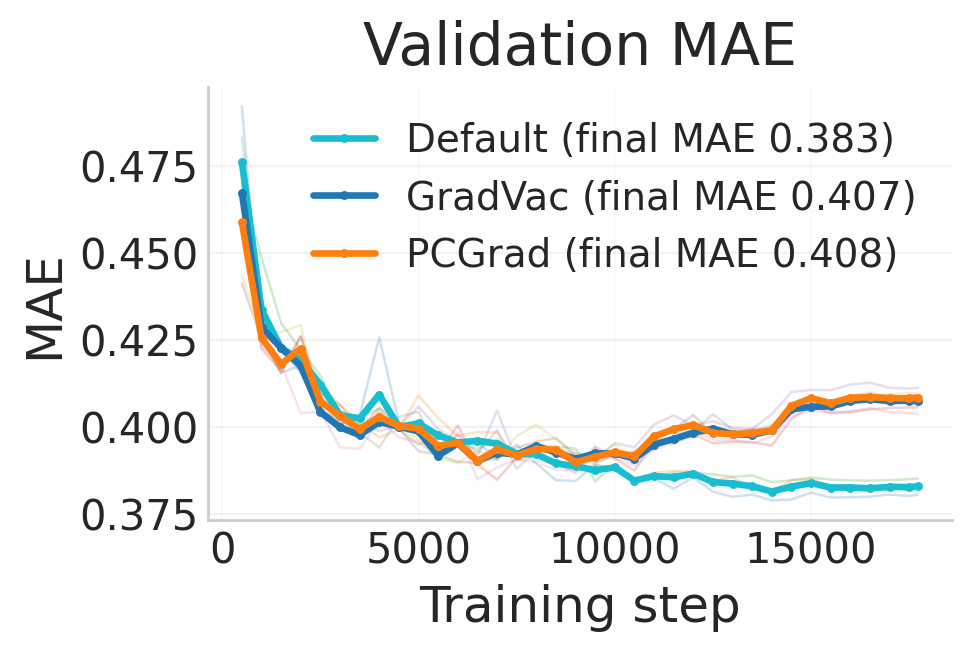

In [15]:
with plt.rc_context({
    "font.size": 17,
    "axes.titlesize": 21,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
    "lines.linewidth": 1.8,
}):
    fig, ax = plt.subplots(figsize=(4.8, 3.2), dpi=200)

    for (group, run_name), run_df in df.groupby(["group", "run_name"], sort=False):
        ax.plot(
            run_df["step"],
            run_df["mae"],
            linewidth=0.9,
            alpha=0.22,
            label=None,
        )

    mean_df = (
        df.groupby(["group", "step"], as_index=False)["mae"]
          .mean()
          .sort_values(["group", "step"])
    )

    for group, group_df in mean_df.groupby("group", sort=False):
        final_mae = group_df.sort_values("step")["mae"].iloc[-1]
        ax.plot(
            group_df["step"],
            group_df["mae"],
            linewidth=2.4,
            marker="o",
            markersize=3.2,
            markeredgewidth=0,
            label=f"{group} (final MAE {final_mae:.3f})",
        )

    ax.set_title("Validation MAE", pad=8)
    ax.set_xlabel("Training step")
    ax.set_ylabel("MAE")
    ax.legend(frameon=False, loc="best", handlelength=1.6)
    ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
    ax.grid(True, axis="x", alpha=0.12, linewidth=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout(pad=0.3)
    plt.show()

## Plot Training Loss

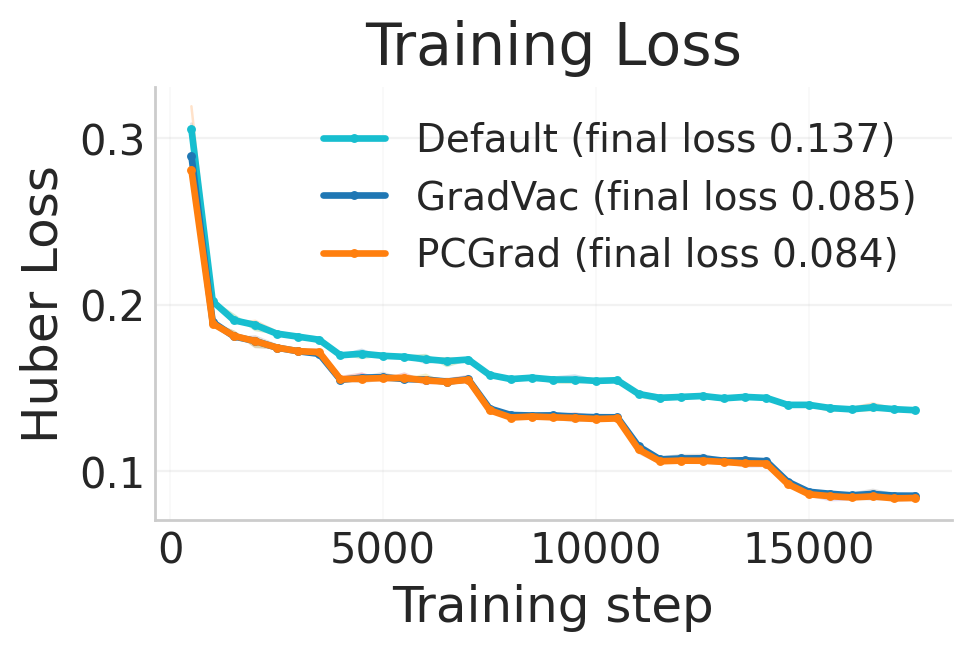

In [16]:
with plt.rc_context({
    "font.size": 17,
    "axes.titlesize": 21,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
    "lines.linewidth": 1.8,
}):
    fig, ax = plt.subplots(figsize=(4.8, 3.2), dpi=200)

    for (group, run_name), run_df in loss_df.groupby(["group", "run_name"], sort=False):
        ax.plot(
            run_df["step"],
            run_df["loss"],
            linewidth=0.9,
            alpha=0.22,
            label=None,
        )

    mean_loss_df = (
        loss_df.groupby(["group", "step"], as_index=False)["loss"]
          .mean()
          .sort_values(["group", "step"])
    )

    for group, group_df in mean_loss_df.groupby("group", sort=False):
        final_loss = group_df.sort_values("step")["loss"].iloc[-1]
        ax.plot(
            group_df["step"],
            group_df["loss"],
            linewidth=2.4,
            marker="o",
            markersize=3.2,
            markeredgewidth=0,
            label=f"{group} (final loss {final_loss:.3f})",
        )

    ax.set_title("Training Loss", pad=8)
    ax.set_xlabel("Training step")
    ax.set_ylabel("Huber Loss")
    ax.legend(frameon=False, loc="best", handlelength=1.6)
    ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
    ax.grid(True, axis="x", alpha=0.12, linewidth=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout(pad=0.3)
    plt.show()

## Best Point Per Group

In [17]:
best_points = (
    df.loc[df.groupby(["group", "run_name"])["mae"].idxmin()]
      .sort_values(["group", "mae"])
      [["group", "run_name", "step", "mae", "metric", "run_id"]]
)

display(best_points)

,group,run_name,step,mae,metric,run_id
27,Default,lora_bert_base_seed1_lora_bert_default_default,14000,0.378810,eval/rounded_mae,v4gu5ea5
63,Default,lora_bert_base_seed2_lora_bert_default_default,14000,0.381230,eval/rounded_mae,j7e6tkln
99,Default,lora_bert_base_seed3_lora_bert_default_default,14000,0.384087,eval/rounded_mae,q2q74poa
228,GradVac,lora_bert_base_seed1_lora_bert_default_gradvac,6500,0.384960,eval/rounded_mae,z9cnykfh
266,GradVac,lora_bert_base_seed2_lora_bert_default_gradvac,7500,0.387857,eval/rounded_mae,j92b3mfp
299,GradVac,lora_bert_base_seed3_lora_bert_default_gradvac,6000,0.389564,eval/rounded_mae,24mfmj1x
121,PCGrad,lora_bert_base_seed1_lora_bert_default_pcgrad,7000,0.384762,eval/rounded_mae,wd1vsvg1
198,PCGrad,lora_bert_base_seed3_lora_bert_default_pcgrad,9500,0.389405,eval/rounded_mae,xyq08py8
158,PCGrad,lora_bert_base_seed2_lora_bert_default_pcgrad,7500,0.390198,eval/rounded_mae,xwyocgie
